# California housing 
## Regression - förutsäga bostadsvärde

## EDA

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [3]:
df = pd.read_csv("housing.csv")

display(df.head())

print()
df.info()

display(df.describe().T)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY



<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


In [6]:
print("--Datatyper i datasetet--\n")
print(df.dtypes)

--Datatyper i datasetet--

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object


### Saknade värden

- För att hantera saknade värden så imputerar vi dem med medianen

In [64]:
print("Shape:", df.shape)
print("\n*** Saknade värden per kolumn ***\n")
print(df.isna().sum())

Shape: (20640, 10)

*** Saknade värden per kolumn ***

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


### Features

In [65]:
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"] / df["households"]

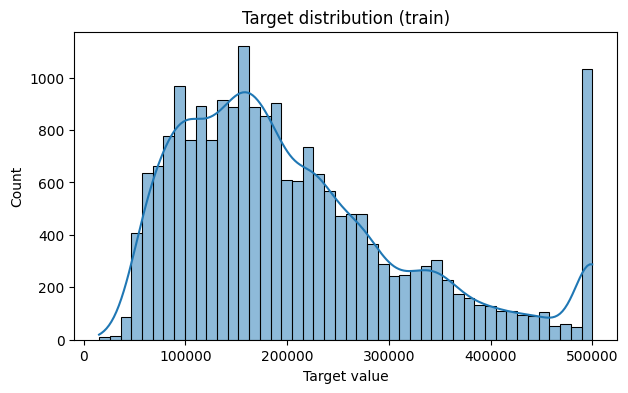

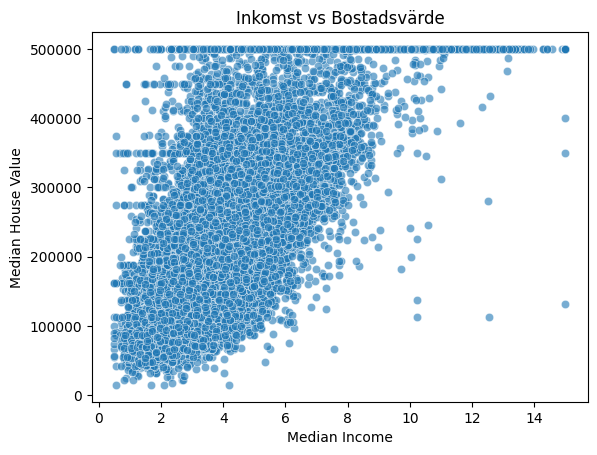

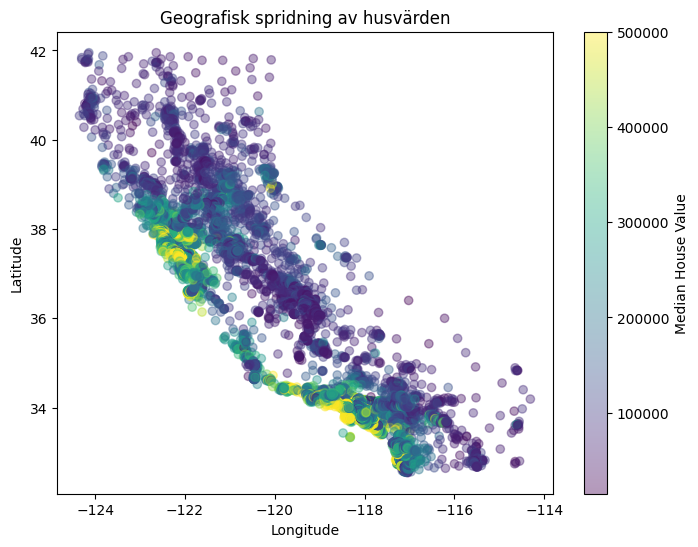

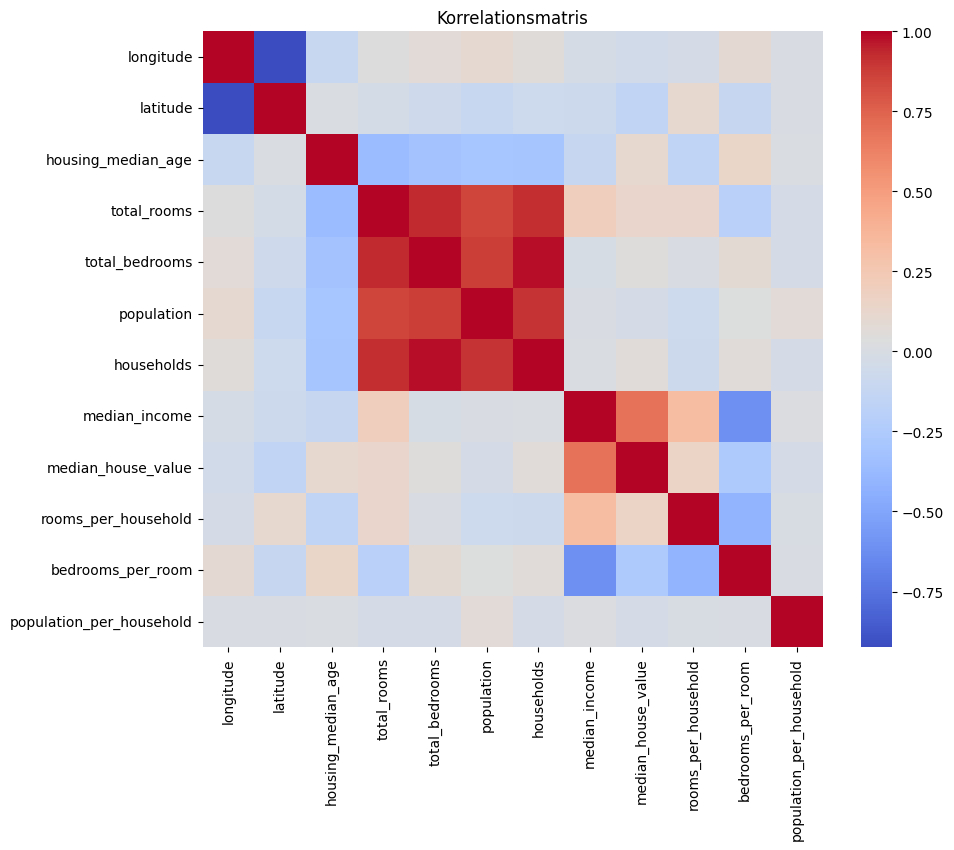

In [ ]:
plt.figure(figsize=(7,4))
sns.histplot(df["median_house_value"], kde=True)
plt.title("Target distribution (train)")
plt.xlabel("Target value")
plt.show()

plt.figure()
sns.scatterplot(x="median_income", y="median_house_value", data=df, alpha=0.6)
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Inkomst vs Bostadsvärde")
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(df["longitude"], df["latitude"],
            c=df["median_house_value"],
            cmap="viridis", alpha=0.4)
plt.colorbar(label="Median House Value")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geografisk spridning av husvärden")
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", annot=False)
plt.title("Korrelationsmatris")
plt.show()

## Split + preprocessing

In [67]:
target_col = "median_house_value"
X = df.drop(columns=[target_col])
y = df[target_col]

In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
)

numerical_features = X_train.select_dtypes(include=["int64","float64"]).columns
categorical_features = ["ocean_proximity"]

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train positive rate:", y_train.mean().round(3), "Test positive rate:", y_test.mean().round(3))

Train: (15480, 12) Test: (5160, 12)
Train positive rate: 207034.892 Test positive rate: 206318.591


In [69]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

## Modellering

Här används Dummyregressor som baseline, och Linear Regression och Random Forest för de andra modellerna att träna datan på


In [70]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def cv_model(model, X, y):
    scores = cross_val_score(
        model, 
        X,
        y,
        scoring="neg_root_mean_squared_error",
        cv=kf
    )
    return -scores.mean()

### Baseline

In [71]:
baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DummyRegressor(strategy="mean"))
])

baseline_scores = cv_model(baseline_model, X_train, y_train)
print(baseline_scores.mean())

115522.20221816306


### Linear regression

In [72]:
linear_reg_pl = Pipeline([("preprocessor", preprocessor), ("model", LinearRegression())])

lin_reg_scores = cv_model(linear_reg_pl, X_train, y_train)

print(lin_reg_scores)

68088.0021208918


### Random forest

In [73]:
rand_forest_pl = Pipeline([
    ("preprocessor", preprocessor), 
    ("model", RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE))
    ])

rand_forest_scores = cv_model(rand_forest_pl, X_train, y_train)

print(rand_forest_scores.mean())

50559.796357523795


In [74]:
results = pd.DataFrame({
    "Model": ["Baseline", "Linear Regression", "Random Forest"],
    "CV_RMSE": [
        baseline_scores,
        lin_reg_scores,
        rand_forest_scores
    ]
})

results.sort_values("CV_RMSE")

,Model,CV_RMSE
2,Random Forest,50559.796358
1,Linear Regression,68088.002121
0,Baseline,115522.202218


## Optimera en modell

Här valdes Random Forest för optimering

In [75]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    rand_forest_pl,
    param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

In [76]:
grid_search.fit(X_train, y_train)
print("Best CV score:", -grid_search.best_score_)
print("Best params:", grid_search.best_params_)

Best CV score: 51076.18895370418
Best params: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}


In [77]:
def evaluate_regression(y_true, y_pred) -> dict:
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
    }

## Utvärdering testdata

In [78]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

test_results = evaluate_regression(y_test, y_pred)

results_df = pd.DataFrame([test_results])
results_df.insert(0, "Model", "Random Forest (Tuned)")

results_df

,Model,MAE,RMSE,R2
0,Random Forest (Tuned),31838.799127,49152.45135,0.817418


In [79]:
baseline_model.fit(X_train, y_train)
linear_reg_pl.fit(X_train, y_train)
rand_forest_pl.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)
lin_pred = linear_reg_pl.predict(X_test)
rf_pred = rand_forest_pl.predict(X_test)
best_pred = best_model.predict(X_test)

baseline_results = evaluate_regression(y_test, baseline_pred)
lin_results = evaluate_regression(y_test, lin_pred)
rf_results = evaluate_regression(y_test, rf_pred)
best_results = evaluate_regression(y_test, best_pred)

results_df = pd.DataFrame([
    {"Model": "Baseline (Dummy)", **baseline_results},
    {"Model": "Linear Regression", **lin_results},
    {"Model": "Random Forest", **rf_results},
    {"Model": "Random Forest (Tuned)", **best_results},
])

results_df

,Model,MAE,RMSE,R2
0,Baseline (Dummy),91004.749905,115033.447900,-0.000039
1,Linear Regression,49355.754508,68429.860721,0.646117
2,Random Forest,31925.663151,49264.520882,0.816584
3,Random Forest (Tuned),31838.799127,49152.451350,0.817418
